# 问题二：四种建模路线统一对比

本 notebook 在**相同样本、相同训练/测试划分、相同模型参数**下比较：

```text
1. p2_diff_hurdle：
   |截断差分| < 0.1 映射为 0；
   XGBoost 判断零/非零；
   MLP、Random Forest、LightGBM 在非零样本上拟合差分。

2. p2_diff：
   MLP、Random Forest、LightGBM 使用全部样本直接拟合截断差分。

3. p2_raw：
   MLP、Random Forest、LightGBM 直接拟合差分前的原始 FILT. NTU。

4. persistence：
   不训练模型，直接使用上一时刻真实 FILT. NTU 作为当前预测值。
```

差分路线的原始值预测为：

```text
预测 FILT.NTU_t = 真实 FILT.NTU_{t-1} + 预测差分_t
```

四条路线最终统一使用原始 `FILT. NTU` 的 MAE、RMSE、R²进行比较。

## 1. 导入依赖与参数

In [1]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 260)

TARGET_COL = "FILT. NTU"
RANDOM_STATE = 42
TEST_SIZE = 0.20
RECORD_INTERVAL_HOURS = 2
DIFF_CLIP_LOWER = -1.0
DIFF_CLIP_UPPER = 1.0
DIFF_ZERO_THRESHOLD = 0.1
SIGNIFICANT_DIFF_THRESHOLD = 0.01

CORE_FEATURES = ["R/W NTU", "R/W PH", "ALUM", "F/RIDE", "R/W FLOW"]
EXOG_LEVEL_LAGS = list(range(0, 7))
TARGET_HISTORY_LAGS = [1, 2, 3]



## 2. 读取并预处理数据

In [2]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    for root in [cwd] + list(cwd.parents):
        for candidate in [root / "data" / filename, root / filename]:
            if candidate.exists():
                return candidate
    matches = list(cwd.rglob(filename))
    if matches:
        return matches[0]
    raise FileNotFoundError(filename)


def construct_datetime(data):
    data = data.copy()
    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data
    date_col = next(c for c in ["DATE", "Date", "date"] if c in data.columns)
    time_col = next(c for c in ["TIME", "Time", "time"] if c in data.columns)
    data["DATETIME"] = pd.to_datetime(
        data[date_col].astype(str).str.split().str[0]
        + " "
        + data[time_col].astype(str).str.split().str[-1],
        errors="coerce",
    )
    return data


DATA_PATH = locate_merged_file()
PROJECT_ROOT = DATA_PATH.parent.parent if DATA_PATH.parent.name == "data" else Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "problem2_method_comparison"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
df = construct_datetime(pd.read_excel(DATA_PATH))
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)
df["OP_DATE"] = df["DATETIME"].dt.date
before_7 = df["DATETIME"].dt.hour < 7
df.loc[before_7, "OP_DATE"] = (
    df.loc[before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

available_features = [c for c in CORE_FEATURES if c in df.columns]
data = df[["DATETIME", "OP_DATE", TARGET_COL] + available_features].copy()

for col in [TARGET_COL] + available_features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

for col, value in {"F/RIDE": 0, "R/W PH": 7, "ALUM": 0.06}.items():
    if col in data.columns:
        data[col] = data[col].fillna(value)

for col in [TARGET_COL] + available_features:
    if col not in {"F/RIDE", "R/W PH", "ALUM"}:
        data[col] = (
            data[col]
            .interpolate(method="linear", limit_direction="both")
            .ffill()
            .bfill()
        )

data["PREVIOUS_FILT_NTU"] = data[TARGET_COL].shift(1)
data["DIFF_FILT_NTU"] = data[TARGET_COL] - data["PREVIOUS_FILT_NTU"]
data["DIFF_FILT_NTU_CLIP1"] = data["DIFF_FILT_NTU"].clip(-1, 1)
data["DIFF_FILT_NTU_HURDLE01"] = data["DIFF_FILT_NTU_CLIP1"].mask(
    data["DIFF_FILT_NTU_CLIP1"].abs() < DIFF_ZERO_THRESHOLD,
    0.0,
)

print("数据文件：", DATA_PATH)
print("数据规模：", data.shape)
print("非零 Hurdle 比例：", (data["DIFF_FILT_NTU_HURDLE01"] != 0).mean())
display(data.head())

数据文件： /Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
数据规模： (5460, 12)
非零 Hurdle 比例： 0.0836996336996337


,DATETIME,OP_DATE,FILT. NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW,PREVIOUS_FILT_NTU,DIFF_FILT_NTU,DIFF_FILT_NTU_CLIP1,DIFF_FILT_NTU_HURDLE01
0,2025-01-01 07:00:00,2025-01-01,0.04,150,7.0,0.04,0.0,45.3,NaN,NaN,NaN,NaN
1,2025-01-01 09:00:00,2025-01-01,0.05,120,7.0,0.04,0.0,45.2,0.04,0.01,0.01,0.0
2,2025-01-01 11:00:00,2025-01-01,0.05,82,7.0,0.04,0.0,44.9,0.05,0.00,0.00,0.0
3,2025-01-01 13:00:00,2025-01-01,0.05,62,7.0,0.04,0.0,44.9,0.05,0.00,0.00,0.0
4,2025-01-01 15:00:00,2025-01-01,0.05,56,7.0,0.04,0.0,44.5,0.05,0.00,0.00,0.0


## 3. 构造候选 lag 与共同训练/测试划分

In [3]:
def safe_name(col):
    return (
        str(col)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(".", "")
        .replace("+", "plus")
        .replace("-", "_")
    )


comparison_data = data.copy()
exog_candidates = {}

for variable in available_features:
    exog_candidates[variable] = []
    for lag in EXOG_LEVEL_LAGS:
        name = f"{safe_name(variable)}_lag{lag}"
        comparison_data[name] = comparison_data[variable].shift(lag)
        exog_candidates[variable].append(name)

method_targets = {
    "p2_diff_hurdle": "DIFF_FILT_NTU_HURDLE01",
    "p2_diff": "DIFF_FILT_NTU_CLIP1",
    "p2_raw": TARGET_COL,
}
target_history_sources = {
    "p2_diff_hurdle": "DIFF_FILT_NTU_HURDLE01",
    "p2_diff": "DIFF_FILT_NTU_CLIP1",
    "p2_raw": TARGET_COL,
}

history_candidates = {}
for method, source in target_history_sources.items():
    history_candidates[method] = []
    for lag in TARGET_HISTORY_LAGS:
        name = f"{safe_name(source)}_{method}_lag{lag}"
        comparison_data[name] = comparison_data[source].shift(lag)
        history_candidates[method].append(name)

required = ["DATETIME", "PREVIOUS_FILT_NTU", TARGET_COL]
comparison_data = comparison_data.dropna(subset=required).reset_index(drop=True)

all_indices = np.arange(len(comparison_data))
hurdle_occurrence = (
    comparison_data[method_targets["p2_diff_hurdle"]] != 0
).astype(int)
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=hurdle_occurrence,
)

train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

print("共同训练样本：", len(train_indices))
print("共同测试样本：", len(test_indices))

共同训练样本： 4367
共同测试样本： 1092


## 4. 各路线仅使用共同训练集选择最佳 lag

In [4]:
def select_best_lags(method):
    target = method_targets[method]
    selected = []
    records = []
    candidate_groups = {**exog_candidates, f"{method}_target_history": history_candidates[method]}
    train_subset = comparison_data.iloc[train_indices]

    for group, candidates in candidate_groups.items():
        best = None
        for feature in candidates:
            temp = train_subset[[target, feature]].dropna()
            spearman = (
                temp[feature].corr(temp[target], method="spearman")
                if len(temp) >= 10
                else np.nan
            )
            score = abs(spearman) if pd.notna(spearman) else np.nan
            record = {
                "method": method,
                "group": group,
                "feature": feature,
                "spearman": spearman,
                "abs_spearman": score,
                "n": len(temp),
            }
            if best is None or (
                pd.notna(score)
                and (pd.isna(best["abs_spearman"]) or score > best["abs_spearman"])
            ):
                best = record
        selected.append(best["feature"])
        records.append(best)
    return selected, records


method_features = {}
selection_records = []
for method in method_targets:
    method_features[method], records = select_best_lags(method)
    selection_records.extend(records)

feature_selection_df = pd.DataFrame(selection_records)
display(feature_selection_df)
for method, features in method_features.items():
    print(method, features)

,method,group,feature,spearman,abs_spearman,n
0,p2_diff_hurdle,R/W NTU,R_W_NTU_lag0,0.023059,0.023059,4367
1,p2_diff_hurdle,R/W PH,R_W_PH_lag0,0.008431,0.008431,4367
2,p2_diff_hurdle,ALUM,ALUM_lag1,-0.022195,0.022195,4367
3,p2_diff_hurdle,F/RIDE,F_RIDE_lag4,0.017711,0.017711,4364
4,p2_diff_hurdle,R/W FLOW,R_W_FLOW_lag3,-0.037883,0.037883,4365
5,p2_diff_hurdle,p2_diff_hurdle_target_history,DIFF_FILT_NTU_HURDLE01_p2_diff_hurdle_lag1,0.059157,0.059157,4366
6,p2_diff,R/W NTU,R_W_NTU_lag2,0.037939,0.037939,4366
7,p2_diff,R/W PH,R_W_PH_lag0,0.008396,0.008396,4367
8,p2_diff,ALUM,ALUM_lag0,-0.035299,0.035299,4367
9,p2_diff,F/RIDE,F_RIDE_lag0,-0.015465,0.015465,4367


p2_diff_hurdle ['R_W_NTU_lag0', 'R_W_PH_lag0', 'ALUM_lag1', 'F_RIDE_lag4', 'R_W_FLOW_lag3', 'DIFF_FILT_NTU_HURDLE01_p2_diff_hurdle_lag1']
p2_diff ['R_W_NTU_lag2', 'R_W_PH_lag0', 'ALUM_lag0', 'F_RIDE_lag0', 'R_W_FLOW_lag3', 'DIFF_FILT_NTU_CLIP1_p2_diff_lag2']
p2_raw ['R_W_NTU_lag6', 'R_W_PH_lag6', 'ALUM_lag5', 'F_RIDE_lag0', 'R_W_FLOW_lag6', 'FILT_NTU_p2_raw_lag1']


## 5. 定义统一模型与指标

In [5]:
def build_regressors():
    return {
        "MLP": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=0.001,
                max_iter=2000,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=RANDOM_STATE,
            )),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=500,
                random_state=RANDOM_STATE,
                max_features="sqrt",
                min_samples_leaf=2,
                n_jobs=-1,
            )),
        ]),
        "LightGBM": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            )),
        ]),
    }


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def classifier_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
    }

## 6. 训练 Hurdle 差分路线

In [6]:
method = "p2_diff_hurdle"
features = method_features[method]
target = method_targets[method]

X_train_h = comparison_data.iloc[train_indices][features]
X_test_h = comparison_data.iloc[test_indices][features]
y_train_h = comparison_data.iloc[train_indices][target]
y_test_h = comparison_data.iloc[test_indices][target]
occ_train = (y_train_h != 0).astype(int)
occ_test = (y_test_h != 0).astype(int)

negative_count = int((occ_train == 0).sum())
positive_count = int((occ_train == 1).sum())
weight_candidates = sorted(set([1.0, 2.0, 4.0, 6.0, round(negative_count / positive_count, 4)]))
threshold_candidates = np.round(np.arange(0.30, 0.81, 0.05), 2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuning_records = []

for weight in weight_candidates:
    probabilities = np.zeros(len(X_train_h))
    for fold_train, fold_valid in cv.split(X_train_h, occ_train):
        classifier = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.85,
                colsample_bytree=0.85,
                scale_pos_weight=weight,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])
        classifier.fit(X_train_h.iloc[fold_train], occ_train.iloc[fold_train])
        probabilities[fold_valid] = classifier.predict_proba(
            X_train_h.iloc[fold_valid]
        )[:, 1]

    for threshold in threshold_candidates:
        prediction = (probabilities >= threshold).astype(int)
        tuning_records.append({
            "weight": weight,
            "threshold": threshold,
            **classifier_metrics(occ_train, prediction, probabilities),
        })

hurdle_tuning_df = pd.DataFrame(tuning_records).sort_values(
    ["F1", "Balanced_Accuracy", "Accuracy"],
    ascending=[False, False, False],
).reset_index(drop=True)
best_hurdle = hurdle_tuning_df.iloc[0]

hurdle_classifier = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=float(best_hurdle["weight"]),
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
hurdle_classifier.fit(X_train_h, occ_train)
hurdle_test_probability = hurdle_classifier.predict_proba(X_test_h)[:, 1]
hurdle_test_occurrence = (
    hurdle_test_probability >= float(best_hurdle["threshold"])
).astype(int)
hurdle_classifier_test = classifier_metrics(
    occ_test, hurdle_test_occurrence, hurdle_test_probability
)

comparison_records = []
prediction_frames = []
saved_models = {}

nonzero_train = occ_train == 1
for model_name, regressor in build_regressors().items():
    regressor.fit(X_train_h.loc[nonzero_train], y_train_h.loc[nonzero_train])
    predicted_diff = np.clip(
        regressor.predict(X_test_h), DIFF_CLIP_LOWER, DIFF_CLIP_UPPER
    )
    predicted_diff = np.where(hurdle_test_occurrence == 1, predicted_diff, 0.0)
    predicted_level = (
        comparison_data.iloc[test_indices]["PREVIOUS_FILT_NTU"].to_numpy()
        + predicted_diff
    )
    actual_level = comparison_data.iloc[test_indices][TARGET_COL].to_numpy()
    metrics = regression_metrics(actual_level, predicted_level)
    comparison_records.append({
        "method": method,
        "model": model_name,
        **{f"level_{key}": value for key, value in metrics.items()},
        "classifier_Accuracy": hurdle_classifier_test["Accuracy"],
        "classifier_F1": hurdle_classifier_test["F1"],
    })
    prediction_frames.append(pd.DataFrame({
        "DATETIME": comparison_data.iloc[test_indices]["DATETIME"].to_numpy(),
        "method": method,
        "model": model_name,
        "actual_FILT_NTU": actual_level,
        "predicted_FILT_NTU": predicted_level,
        "predicted_difference": predicted_diff,
    }))
    saved_models[(method, model_name)] = regressor

display(hurdle_classifier_test)

{'Accuracy': 0.9395604395604396,
 'Balanced_Accuracy': 0.7622377622377623,
 'Precision': 0.6666666666666666,
 'Recall': 0.5494505494505495,
 'F1': 0.6024096385542169,
 'ROC_AUC': 0.8656727887497118}

## 7. 训练直接差分路线

In [7]:
method = "p2_diff"
features = method_features[method]
target = method_targets[method]
X_train_d = comparison_data.iloc[train_indices][features]
X_test_d = comparison_data.iloc[test_indices][features]
y_train_d = comparison_data.iloc[train_indices][target]
y_test_d = comparison_data.iloc[test_indices][target]

for model_name, regressor in build_regressors().items():
    regressor.fit(X_train_d, y_train_d)
    predicted_diff = np.clip(
        regressor.predict(X_test_d), DIFF_CLIP_LOWER, DIFF_CLIP_UPPER
    )
    predicted_level = (
        comparison_data.iloc[test_indices]["PREVIOUS_FILT_NTU"].to_numpy()
        + predicted_diff
    )
    actual_level = comparison_data.iloc[test_indices][TARGET_COL].to_numpy()
    metrics = regression_metrics(actual_level, predicted_level)
    comparison_records.append({
        "method": method,
        "model": model_name,
        **{f"level_{key}": value for key, value in metrics.items()},
        "classifier_Accuracy": np.nan,
        "classifier_F1": np.nan,
    })
    prediction_frames.append(pd.DataFrame({
        "DATETIME": comparison_data.iloc[test_indices]["DATETIME"].to_numpy(),
        "method": method,
        "model": model_name,
        "actual_FILT_NTU": actual_level,
        "predicted_FILT_NTU": predicted_level,
        "predicted_difference": predicted_diff,
    }))
    saved_models[(method, model_name)] = regressor

# Persistence 基线：直接预测为上一时刻真实 FILT. NTU
method = "persistence"
model_name = "Previous value"
actual_level = comparison_data.iloc[test_indices][TARGET_COL].to_numpy()
predicted_level = comparison_data.iloc[test_indices]["PREVIOUS_FILT_NTU"].to_numpy()
metrics = regression_metrics(actual_level, predicted_level)
comparison_records.append({
    "method": method,
    "model": model_name,
    **{f"level_{key}": value for key, value in metrics.items()},
    "classifier_Accuracy": np.nan,
    "classifier_F1": np.nan,
})
prediction_frames.append(pd.DataFrame({
    "DATETIME": comparison_data.iloc[test_indices]["DATETIME"].to_numpy(),
    "method": method,
    "model": model_name,
    "actual_FILT_NTU": actual_level,
    "predicted_FILT_NTU": predicted_level,
    "predicted_difference": 0.0,
}))

## 8. 训练原始值直接拟合路线

In [8]:
method = "p2_raw"
features = method_features[method]
target = method_targets[method]
X_train_r = comparison_data.iloc[train_indices][features]
X_test_r = comparison_data.iloc[test_indices][features]
y_train_r = comparison_data.iloc[train_indices][target]
y_test_r = comparison_data.iloc[test_indices][target]

for model_name, regressor in build_regressors().items():
    regressor.fit(X_train_r, y_train_r)
    predicted_level = regressor.predict(X_test_r)
    actual_level = y_test_r.to_numpy()
    metrics = regression_metrics(actual_level, predicted_level)
    comparison_records.append({
        "method": method,
        "model": model_name,
        **{f"level_{key}": value for key, value in metrics.items()},
        "classifier_Accuracy": np.nan,
        "classifier_F1": np.nan,
    })
    prediction_frames.append(pd.DataFrame({
        "DATETIME": comparison_data.iloc[test_indices]["DATETIME"].to_numpy(),
        "method": method,
        "model": model_name,
        "actual_FILT_NTU": actual_level,
        "predicted_FILT_NTU": predicted_level,
        "predicted_difference": np.nan,
    }))
    saved_models[(method, model_name)] = regressor

## 9. 汇总对比与可视化

,method,model,level_MAE,level_RMSE,level_R2,classifier_Accuracy,classifier_F1,method_label,label
0,p2_raw,Random Forest,0.070436,0.345909,0.706606,NaN,NaN,Direct raw level,Direct raw level / Random Forest
1,p2_raw,LightGBM,0.079536,0.350760,0.698319,NaN,NaN,Direct raw level,Direct raw level / LightGBM
2,p2_raw,MLP,0.069413,0.351005,0.697898,NaN,NaN,Direct raw level,Direct raw level / MLP
3,p2_diff_hurdle,LightGBM,0.064879,0.355889,0.689432,0.93956,0.60241,Hurdle difference,Hurdle difference / LightGBM
4,p2_diff_hurdle,Random Forest,0.062417,0.356004,0.689230,0.93956,0.60241,Hurdle difference,Hurdle difference / Random Forest
5,p2_diff,MLP,0.069211,0.356121,0.689027,NaN,NaN,Direct difference,Direct difference / MLP
6,p2_diff,Random Forest,0.066349,0.360282,0.681717,NaN,NaN,Direct difference,Direct difference / Random Forest
7,persistence,Previous value,0.061117,0.362299,0.678144,NaN,NaN,Persistence baseline,Persistence baseline / Previous value
8,p2_diff,LightGBM,0.071611,0.363483,0.676036,NaN,NaN,Direct difference,Direct difference / LightGBM
9,p2_diff_hurdle,MLP,0.062383,0.364961,0.673396,0.93956,0.60241,Hurdle difference,Hurdle difference / MLP


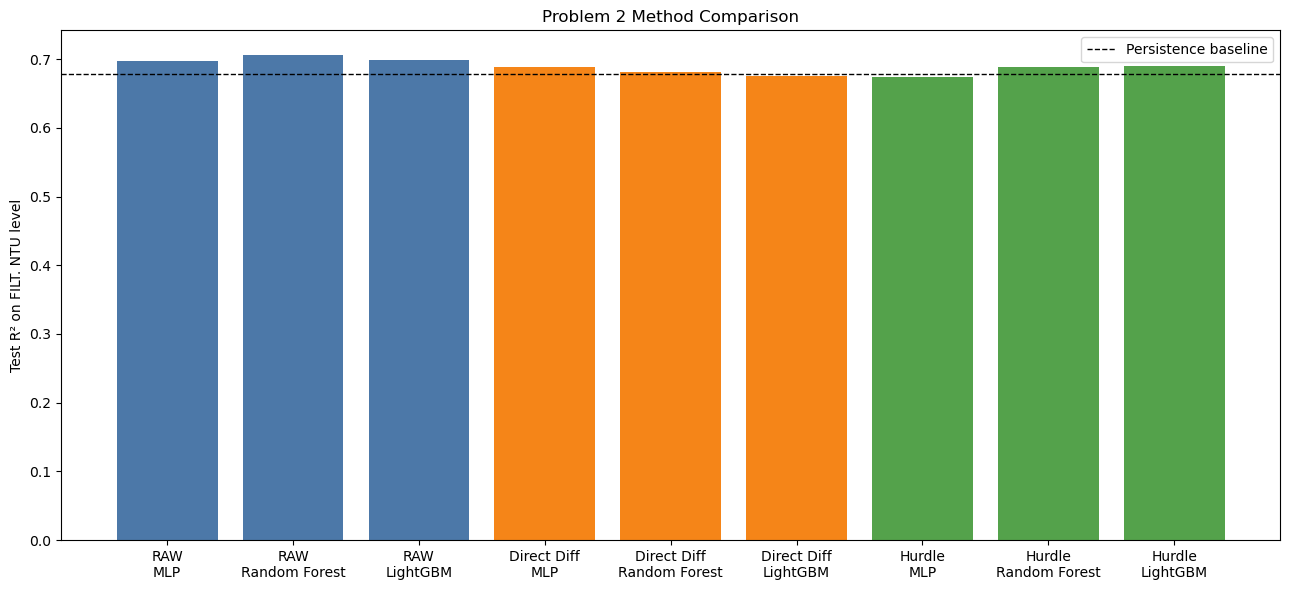

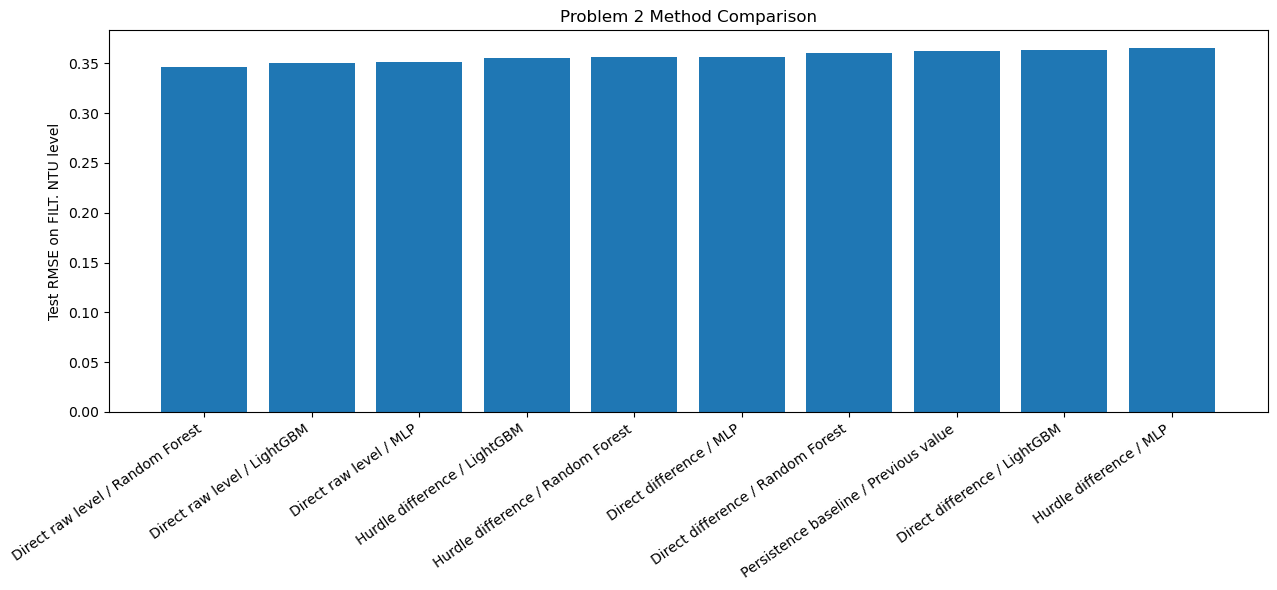

In [9]:
comparison_df = pd.DataFrame(comparison_records).sort_values(
    ["level_R2", "level_RMSE"],
    ascending=[False, True],
).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

method_labels = {
    "p2_diff_hurdle": "Hurdle difference",
    "p2_diff": "Direct difference",
    "p2_raw": "Direct raw level",
    "persistence": "Persistence baseline",
}
comparison_df["method_label"] = comparison_df["method"].map(method_labels)
comparison_df["label"] = comparison_df["method_label"] + " / " + comparison_df["model"]

display(comparison_df)

method_plot_order = ["p2_raw", "p2_diff", "p2_diff_hurdle"]
model_plot_order = ["MLP", "Random Forest", "LightGBM"]
method_plot_names = {
    "p2_raw": "RAW",
    "p2_diff": "Direct Diff",
    "p2_diff_hurdle": "Hurdle",
}
method_plot_colors = {
    "p2_raw": "#4C78A8",
    "p2_diff": "#F58518",
    "p2_diff_hurdle": "#54A24B",
}

r2_plot_df = comparison_df[
    comparison_df["method"].isin(method_plot_order)
].copy()
r2_plot_df["_method_order"] = r2_plot_df["method"].map(
    {name: index for index, name in enumerate(method_plot_order)}
)
r2_plot_df["_model_order"] = r2_plot_df["model"].map(
    {name: index for index, name in enumerate(model_plot_order)}
)
r2_plot_df = r2_plot_df.sort_values(["_method_order", "_model_order"])
r2_plot_df["plot_label"] = (
    r2_plot_df["method"].map(method_plot_names) + "\n" + r2_plot_df["model"]
)

persistence_level_r2 = comparison_df.loc[
    comparison_df["method"].eq("persistence"),
    "level_R2",
].iloc[0]

plt.figure(figsize=(13, 6))
plt.bar(
    r2_plot_df["plot_label"],
    r2_plot_df["level_R2"],
    color=r2_plot_df["method"].map(method_plot_colors),
)
plt.axhline(
    persistence_level_r2,
    color="black",
    linewidth=1,
    linestyle="--",
    label="Persistence baseline",
)
plt.ylabel("Test R² on FILT. NTU level")
plt.title("Problem 2 Method Comparison")
plt.legend()
plt.tight_layout()
r2_path = FIG_DIR / "method_model_r2_comparison.png"
plt.savefig(r2_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(13, 6))
plt.bar(comparison_df["label"], comparison_df["level_RMSE"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Test RMSE on FILT. NTU level")
plt.title("Problem 2 Method Comparison")
plt.tight_layout()
rmse_path = FIG_DIR / "method_model_rmse_comparison.png"
plt.savefig(rmse_path, dpi=300, bbox_inches="tight")
plt.show()

## 10. 统一差分评估：去除上一时刻 FILT.NTU 的影响

所有方法统一转换为对变化量的预测：

- 真实变化量：`actual_FILT_NTU - PREVIOUS_FILT_NTU`
- 原始值模型的预测变化量：`predicted_FILT_NTU - PREVIOUS_FILT_NTU`
- 差分模型沿用其直接输出的预测变化量
- 持续性基线的预测变化量恒为 0

这样可排除上一时刻原始值带来的水平解释能力，直接衡量模型是否预测到了新的变化。

,method,model,diff_MAE,diff_RMSE,diff_R2,direction_accuracy,RMSE_skill_vs_persistence,method_label,label
0,p2_raw,Random Forest,0.070436,0.345909,0.088338,0.293956,0.045239,Direct raw level,Direct raw level / Random Forest
1,p2_raw,LightGBM,0.079536,0.350760,0.062588,0.264652,0.031850,Direct raw level,Direct raw level / LightGBM
2,p2_raw,MLP,0.069413,0.351005,0.061279,0.263736,0.031174,Direct raw level,Direct raw level / MLP
3,p2_diff_hurdle,LightGBM,0.064879,0.355889,0.034972,0.561355,0.017692,Hurdle difference,Hurdle difference / LightGBM
4,p2_diff_hurdle,Random Forest,0.062417,0.356004,0.034347,0.562271,0.017374,Hurdle difference,Hurdle difference / Random Forest
5,p2_diff,MLP,0.069211,0.356121,0.033713,0.246337,0.017052,Direct difference,Direct difference / MLP
6,p2_diff,Random Forest,0.066349,0.360282,0.011001,0.227106,0.005567,Direct difference,Direct difference / Random Forest
7,persistence,Previous value,0.061117,0.362299,-0.000103,0.536630,0.000000,Persistence baseline,Persistence baseline / Previous value
8,p2_diff,LightGBM,0.071611,0.363483,-0.006654,0.232601,-0.003270,Direct difference,Direct difference / LightGBM
9,p2_diff_hurdle,MLP,0.062383,0.364961,-0.014855,0.558608,-0.007348,Hurdle difference,Hurdle difference / MLP


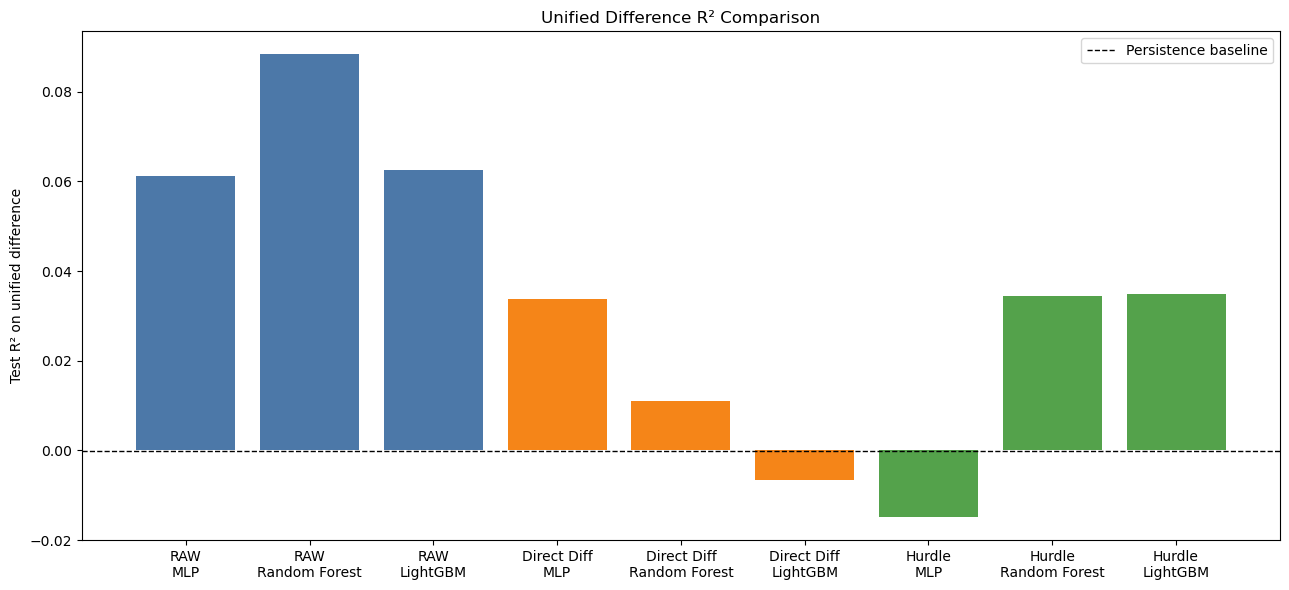

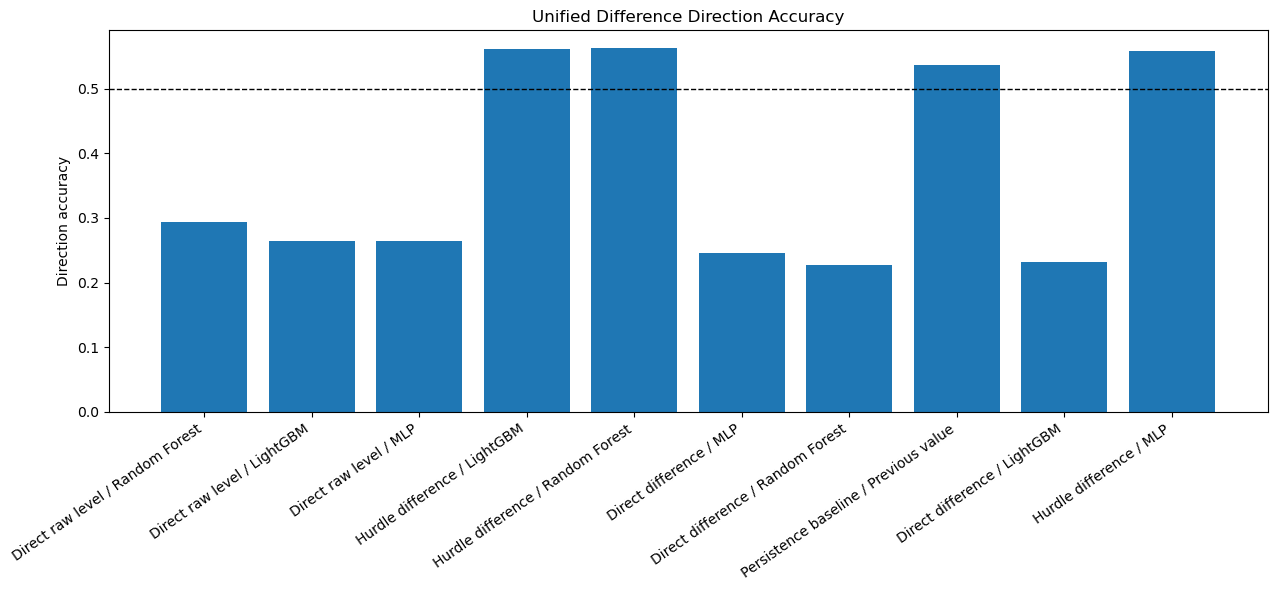

In [10]:
previous_lookup = comparison_data.iloc[test_indices][
    ["DATETIME", "PREVIOUS_FILT_NTU"]
].copy()

predictions_df = predictions_df.merge(
    previous_lookup,
    on="DATETIME",
    how="left",
    validate="many_to_one",
)
predictions_df["actual_difference"] = (
    predictions_df["actual_FILT_NTU"] - predictions_df["PREVIOUS_FILT_NTU"]
)

# 原始值模型没有直接输出差分，因此用预测原值减去同一上一时刻真实值。
missing_difference = predictions_df["predicted_difference"].isna()
predictions_df.loc[missing_difference, "predicted_difference"] = (
    predictions_df.loc[missing_difference, "predicted_FILT_NTU"]
    - predictions_df.loc[missing_difference, "PREVIOUS_FILT_NTU"]
)

difference_records = []
for (method, model), group in predictions_df.groupby(["method", "model"], sort=False):
    metrics = regression_metrics(
        group["actual_difference"],
        group["predicted_difference"],
    )
    direction_accuracy = np.mean(
        np.sign(group["actual_difference"].to_numpy())
        == np.sign(group["predicted_difference"].to_numpy())
    )
    difference_records.append(
        {
            "method": method,
            "model": model,
            "diff_MAE": metrics["MAE"],
            "diff_RMSE": metrics["RMSE"],
            "diff_R2": metrics["R2"],
            "direction_accuracy": direction_accuracy,
        }
    )

difference_comparison_df = pd.DataFrame(difference_records)
persistence_rmse = difference_comparison_df.loc[
    difference_comparison_df["method"].eq("persistence"),
    "diff_RMSE",
].iloc[0]
difference_comparison_df["RMSE_skill_vs_persistence"] = (
    1.0 - difference_comparison_df["diff_RMSE"] / persistence_rmse
)
difference_comparison_df["method_label"] = difference_comparison_df["method"].map(
    method_labels
)
difference_comparison_df["label"] = (
    difference_comparison_df["method_label"]
    + " / "
    + difference_comparison_df["model"]
)
difference_comparison_df = difference_comparison_df.sort_values(
    ["diff_R2", "diff_RMSE"],
    ascending=[False, True],
).reset_index(drop=True)

display(difference_comparison_df)

difference_r2_plot_df = difference_comparison_df[
    difference_comparison_df["method"].isin(method_plot_order)
].copy()
difference_r2_plot_df["_method_order"] = difference_r2_plot_df["method"].map(
    {name: index for index, name in enumerate(method_plot_order)}
)
difference_r2_plot_df["_model_order"] = difference_r2_plot_df["model"].map(
    {name: index for index, name in enumerate(model_plot_order)}
)
difference_r2_plot_df = difference_r2_plot_df.sort_values(
    ["_method_order", "_model_order"]
)
difference_r2_plot_df["plot_label"] = (
    difference_r2_plot_df["method"].map(method_plot_names)
    + "\n"
    + difference_r2_plot_df["model"]
)

persistence_difference_r2 = difference_comparison_df.loc[
    difference_comparison_df["method"].eq("persistence"),
    "diff_R2",
].iloc[0]

plt.figure(figsize=(13, 6))
plt.bar(
    difference_r2_plot_df["plot_label"],
    difference_r2_plot_df["diff_R2"],
    color=difference_r2_plot_df["method"].map(method_plot_colors),
)
plt.axhline(
    persistence_difference_r2,
    color="black",
    linewidth=1,
    linestyle="--",
    label="Persistence baseline",
)
plt.ylabel("Test R² on unified difference")
plt.title("Unified Difference R² Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "method_model_difference_r2_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

plt.figure(figsize=(13, 6))
plt.bar(
    difference_comparison_df["label"],
    difference_comparison_df["direction_accuracy"],
)
plt.axhline(0.5, color="black", linewidth=1, linestyle="--")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Direction accuracy")
plt.title("Unified Difference Direction Accuracy")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "method_model_difference_direction_accuracy.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 11. 排除微小变化后的统一差分评估

仅保留满足以下条件的测试样本：

```text
|FILT.NTU_t - FILT.NTU_{t-1}| >= 0.01
```

排除真实差分绝对值小于 0.01 的近似不变样本后，重新计算各方法的差分 MAE、RMSE、R²、方向准确率，以及相对 persistence 的 RMSE 提升。模型不重新训练，仅改变评估样本。

差分阈值：|difference| >= 0.01
原测试样本数：1092
保留样本数：410
保留比例：37.55%


,method,model,threshold,n_samples,retention_rate,diff_MAE,diff_RMSE,diff_R2,direction_accuracy,RMSE_skill_vs_persistence,method_label,label
0,p2_raw,Random Forest,0.01,410,0.375458,0.162321,0.562555,0.094489,0.626829,0.048535,Direct raw level,Direct raw level / Random Forest
1,p2_raw,LightGBM,0.01,410,0.375458,0.180091,0.569293,0.072666,0.551220,0.037138,Direct raw level,Direct raw level / LightGBM
2,p2_raw,MLP,0.01,410,0.375458,0.157981,0.571635,0.065020,0.570732,0.033176,Direct raw level,Direct raw level / MLP
3,p2_diff_hurdle,LightGBM,0.01,410,0.375458,0.164236,0.578061,0.043881,0.090244,0.022308,Hurdle difference,Hurdle difference / LightGBM
4,p2_diff_hurdle,Random Forest,0.01,410,0.375458,0.159723,0.579756,0.038266,0.092683,0.019441,Hurdle difference,Hurdle difference / Random Forest
5,p2_diff,MLP,0.01,410,0.375458,0.159957,0.580422,0.036056,0.526829,0.018316,Direct difference,Direct difference / MLP
6,p2_diff,Random Forest,0.01,410,0.375458,0.159948,0.587341,0.012938,0.465854,0.006614,Direct difference,Direct difference / Random Forest
7,persistence,Previous value,0.01,410,0.375458,0.160439,0.591251,-0.000248,0.000000,0.000000,Persistence baseline,Persistence baseline / Previous value
8,p2_diff,LightGBM,0.01,410,0.375458,0.166258,0.591885,-0.002396,0.507317,-0.001073,Direct difference,Direct difference / LightGBM
9,p2_diff_hurdle,MLP,0.01,410,0.375458,0.159974,0.594565,-0.011493,0.082927,-0.005605,Hurdle difference,Hurdle difference / MLP


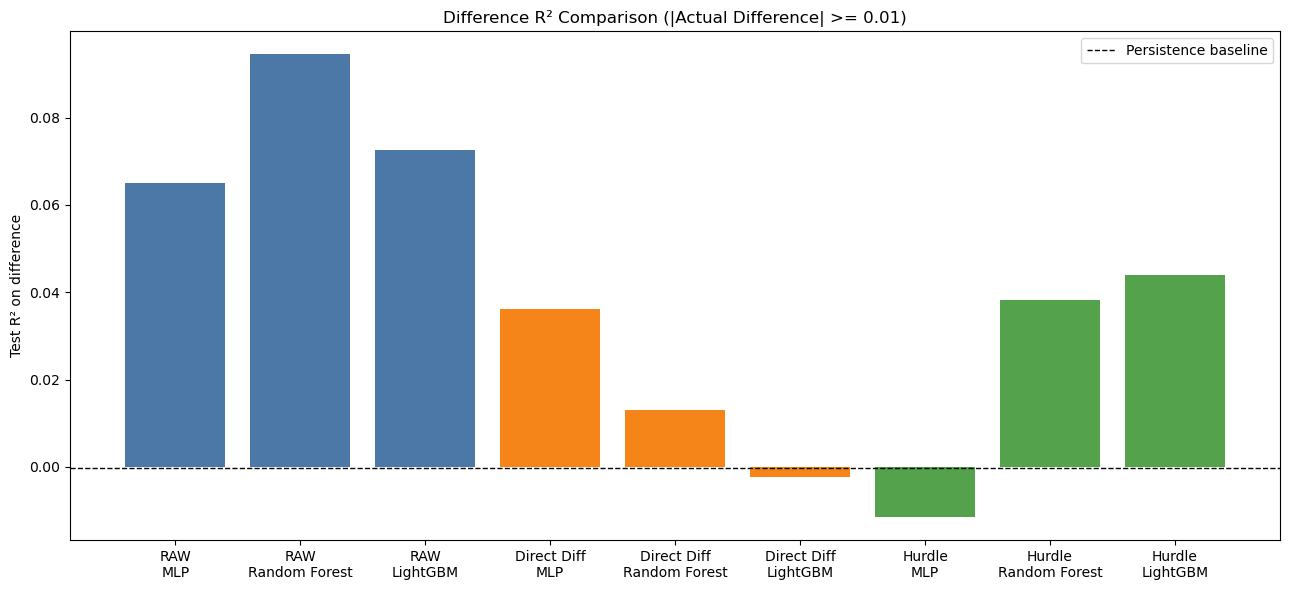

In [11]:
significant_predictions_df = predictions_df.loc[
    predictions_df["actual_difference"].abs() >= SIGNIFICANT_DIFF_THRESHOLD
].copy()

total_test_samples = predictions_df.loc[
    predictions_df["method"].eq("persistence")
].shape[0]
significant_test_samples = significant_predictions_df.loc[
    significant_predictions_df["method"].eq("persistence")
].shape[0]
significant_retention_rate = significant_test_samples / total_test_samples

print(f"差分阈值：|difference| >= {SIGNIFICANT_DIFF_THRESHOLD}")
print(f"原测试样本数：{total_test_samples}")
print(f"保留样本数：{significant_test_samples}")
print(f"保留比例：{significant_retention_rate:.2%}")

significant_difference_records = []
for (method, model), group in significant_predictions_df.groupby(
    ["method", "model"],
    sort=False,
):
    metrics = regression_metrics(
        group["actual_difference"],
        group["predicted_difference"],
    )
    direction_accuracy = np.mean(
        np.sign(group["actual_difference"].to_numpy())
        == np.sign(group["predicted_difference"].to_numpy())
    )
    significant_difference_records.append(
        {
            "method": method,
            "model": model,
            "threshold": SIGNIFICANT_DIFF_THRESHOLD,
            "n_samples": len(group),
            "retention_rate": significant_retention_rate,
            "diff_MAE": metrics["MAE"],
            "diff_RMSE": metrics["RMSE"],
            "diff_R2": metrics["R2"],
            "direction_accuracy": direction_accuracy,
        }
    )

significant_difference_df = pd.DataFrame(significant_difference_records)
significant_persistence_rmse = significant_difference_df.loc[
    significant_difference_df["method"].eq("persistence"),
    "diff_RMSE",
].iloc[0]
significant_difference_df["RMSE_skill_vs_persistence"] = (
    1.0
    - significant_difference_df["diff_RMSE"] / significant_persistence_rmse
)
significant_difference_df["method_label"] = significant_difference_df[
    "method"
].map(method_labels)
significant_difference_df["label"] = (
    significant_difference_df["method_label"]
    + " / "
    + significant_difference_df["model"]
)
significant_difference_df = significant_difference_df.sort_values(
    ["diff_R2", "diff_RMSE"],
    ascending=[False, True],
).reset_index(drop=True)

display(significant_difference_df)

significant_r2_plot_df = significant_difference_df[
    significant_difference_df["method"].isin(method_plot_order)
].copy()
significant_r2_plot_df["_method_order"] = significant_r2_plot_df["method"].map(
    {name: index for index, name in enumerate(method_plot_order)}
)
significant_r2_plot_df["_model_order"] = significant_r2_plot_df["model"].map(
    {name: index for index, name in enumerate(model_plot_order)}
)
significant_r2_plot_df = significant_r2_plot_df.sort_values(
    ["_method_order", "_model_order"]
)
significant_r2_plot_df["plot_label"] = (
    significant_r2_plot_df["method"].map(method_plot_names)
    + "\n"
    + significant_r2_plot_df["model"]
)

significant_persistence_r2 = significant_difference_df.loc[
    significant_difference_df["method"].eq("persistence"),
    "diff_R2",
].iloc[0]

plt.figure(figsize=(13, 6))
plt.bar(
    significant_r2_plot_df["plot_label"],
    significant_r2_plot_df["diff_R2"],
    color=significant_r2_plot_df["method"].map(method_plot_colors),
)
plt.axhline(
    significant_persistence_r2,
    color="black",
    linewidth=1,
    linestyle="--",
    label="Persistence baseline",
)
plt.ylabel("Test R² on difference")
plt.title("Difference R² Comparison (|Actual Difference| >= 0.01)")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "method_model_difference_r2_excluding_below_001.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 12. 保存结果

In [12]:
results_path = OUTPUT_DIR / "problem2_method_comparison.xlsx"
predictions_path = OUTPUT_DIR / "problem2_method_predictions.xlsx"
feature_path = OUTPUT_DIR / "problem2_method_selected_features.xlsx"
difference_results_path = OUTPUT_DIR / "problem2_difference_comparison.xlsx"
significant_difference_path = OUTPUT_DIR / "problem2_difference_excluding_below_001.xlsx"

with pd.ExcelWriter(results_path, engine="openpyxl") as writer:
    comparison_df.to_excel(writer, sheet_name="comparison", index=False)
    feature_selection_df.to_excel(writer, sheet_name="selected_features", index=False)
    hurdle_tuning_df.to_excel(writer, sheet_name="hurdle_tuning", index=False)
    predictions_df.to_excel(writer, sheet_name="predictions", index=False)
    difference_comparison_df.to_excel(
        writer, sheet_name="difference_comparison", index=False
    )
    significant_difference_df.to_excel(
        writer, sheet_name="diff_abs_ge_001", index=False
    )

predictions_df.to_excel(predictions_path, index=False)
feature_selection_df.to_excel(feature_path, index=False)
difference_comparison_df.to_excel(difference_results_path, index=False)
significant_difference_df.to_excel(significant_difference_path, index=False)

for (method, model_name), model in saved_models.items():
    joblib.dump(
        {
            "model": model,
            "features": method_features[method],
            "method": method,
            "target": method_targets[method],
        },
        MODEL_DIR / f"{method}_{model_name.replace(' ', '_')}.joblib",
    )

best = comparison_df.iloc[0]
print("最佳路线：", best["method_label"])
print("最佳模型：", best["model"])
print("测试 R²：", best["level_R2"])
print("结果文件：", results_path)
print(f"差分评估文件：{difference_results_path}")
print(f"排除微小差分评估文件：{significant_difference_path}")


最佳路线： Direct raw level
最佳模型： Random Forest
测试 R²： 0.7066060540782154
结果文件： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_method_comparison/problem2_method_comparison.xlsx
差分评估文件：/Users/jinyu/workspace/2026亚太杯/outputs/problem2_method_comparison/problem2_difference_comparison.xlsx
排除微小差分评估文件：/Users/jinyu/workspace/2026亚太杯/outputs/problem2_method_comparison/problem2_difference_excluding_below_001.xlsx
